# STG and LSPIN Evaluation Notebook

This notebook runs the iterative feature-reduction experiment across the six loaded datasets:
- Breast, defined as "hard" dataset
- madelon, defined as "hard" dataset
- SMK-CAN-187, defined as "medium" dataset
- colon, defined as "medium" dataset
- leukemia, defined as "easy" dataset
- RELATHE, defined as "easy" dataset

## Workflow
1. Initialize notebook environment.
2. Configure paths and load datasets.
3. Apply reproducibility settings (seeding).
4. Run STG/LSPIN feature selection + ExtraTrees evaluation in 5-fold CV.
5. Plot and save train/test curves.
6. Write outputs into a dedicated output folder.
7. Re-run safety checks for repeatability.

## Initialize Imports, Libraries, and Global Configuration

In [ ]:
from __future__ import annotations
import collections as _collections
import hashlib
import os
import random
from pathlib import Path
from typing import Any, Dict, Mapping, MutableMapping, Sequence, Tuple
from collections import abc as _collections_abc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse as sp
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

for _alias in ("Callable", "Iterable", "Mapping", "MutableMapping", "Sequence", "Set"):
    if not hasattr(_collections, _alias):
        setattr(_collections, _alias, getattr(_collections_abc, _alias))

from featselectlib.supervised_feature_selection.Lspin import DataSetMeta, Lspin
from featselectlib.supervised_feature_selection.stg.python.stg import STG

DEFAULT_DATASET_NAMES = ("Breast", "madelon", "SMK-CAN-187", "colon", "leukemia", "RELATHE")
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Base directory: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub
ETree path: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\Algorithms - Partial List\ETree.py
Output directory: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output


## Dataset Paths from Local Data Folder

This section maps dataset file paths under `c:/Users/shlom/Thesis/data`, reports which required datasets exist, and loads available `.mat` files into memory.

In [2]:
DATA_ROOT = Path(r"c:/Users/shlom/Thesis/data")
DATASET_PATHS = {
    "Breast": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "Breast.mat",
    "madelon": DATA_ROOT / "Challenging Data Collections" / "Unaltered Data Sources" / "madelon.mat",
    "SMK-CAN-187": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "SMK-CAN-187.mat",
    "colon": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "colon.mat",
    "leukemia": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" /  "leukemia.mat",
    "RELATHE": DATA_ROOT / "Standard Difficulty Data Collections" / "scikit-feature" / "RELATHE.mat",
}

path_status_df = pd.DataFrame(
    [{"dataset": name, "path": str(path), "exists": path.exists()} for name, path in DATASET_PATHS.items()]
)
display(path_status_df)

,dataset,path,exists
0,Breast,c:\Users\shlom\Thesis\data\Challenging Data Co...,True
1,madelon,c:\Users\shlom\Thesis\data\Challenging Data Co...,True
2,SMK-CAN-187,c:\Users\shlom\Thesis\data\Standard Difficulty...,True
3,colon,c:\Users\shlom\Thesis\data\Standard Difficulty...,True
4,leukemia,c:\Users\shlom\Thesis\data\Standard Difficulty...,True
5,RELATHE,c:\Users\shlom\Thesis\data\Standard Difficulty...,True


## Check and Report Dataset File Paths

In [3]:
from scipy.io import loadmat


def _load_mat_xy(mat_path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(mat_path)

    feature_keys = ("X", "x", "data", "features", "fea")
    label_keys = ("y", "Y", "labels", "label", "target", "gnd")

    X = next((mat[k] for k in feature_keys if k in mat), None)
    y = next((mat[k] for k in label_keys if k in mat), None)

    if X is None or y is None:
        raise KeyError(f"Could not find feature/label keys in {mat_path.name}")

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)
    return X, y


def _load_dataset_xy(path: Path) -> tuple[np.ndarray, np.ndarray]:
    if path.suffix.lower() != ".mat":
        raise ValueError(f"Unsupported dataset format: {path.name}. Only .mat files are supported.")
    return _load_mat_xy(path)


loaded_from_data_folder = {}
missing_from_data_folder = []

for dataset_name, dataset_path in DATASET_PATHS.items():
    if dataset_path.exists():
        X, y = _load_dataset_xy(dataset_path)
        globals()[dataset_name] = (X, y)
        loaded_from_data_folder[dataset_name] = {"shape": X.shape, "labels": np.unique(y).size}
    else:
        missing_from_data_folder.append(dataset_name)

print("Loaded datasets from data folder:")
for name, meta in loaded_from_data_folder.items():
    print(f"- {name}: X shape={meta['shape']}, #classes={meta['labels']}")

if missing_from_data_folder:
    print("\nMissing datasets in data folder:", ", ".join(missing_from_data_folder))

Loaded datasets from data folder:
- Breast: X shape=(97, 24481), #classes=2
- madelon: X shape=(2600, 500), #classes=2
- SMK-CAN-187: X shape=(187, 19993), #classes=2
- colon: X shape=(62, 2000), #classes=2
- leukemia: X shape=(72, 7070), #classes=2
- RELATHE: X shape=(1427, 4322), #classes=2


## Define Functions to Load .mat File Format

In [ ]:
def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)
print("Global seed configured:", SEED)

ETree hash before run: db92e1541faa9f1224dcb9457100295f530fb99dc66c71d65c3a8ab2df2cc9d1
ETree source lines: 37


## Define Feature Selection and Evaluation Pipeline
The following cells define modular functions for baseline ExtraTrees, STG, and LSPIN with 5-fold CV across iterative feature ratios: 100%, 90%, 80%, ..., 10%, and 5%.

In [ ]:
def _as_numpy_array(value: Any) -> np.ndarray:
    if sp.issparse(value):
        return value.toarray()
    if hasattr(value, "to_numpy"):
        return value.to_numpy()
    return np.asarray(value)


def extract_xy(dataset: Any) -> Tuple[np.ndarray, np.ndarray]:
    if isinstance(dataset, (tuple, list)):
        if len(dataset) != 2:
            raise ValueError("Dataset tuple/list must have exactly (X, y).")
        return _as_numpy_array(dataset[0]), np.asarray(dataset[1])

    if isinstance(dataset, Mapping):
        feature_keys = ("X", "x", "data", "features")
        label_keys = ("y", "Y", "labels", "target", "targets")
        X = next((dataset[k] for k in feature_keys if k in dataset), None)
        y = next((dataset[k] for k in label_keys if k in dataset), None)
        if X is None or y is None:
            raise ValueError("Dataset mapping must include feature and label entries.")
        return _as_numpy_array(X), np.asarray(y)

    for feature_attr, label_attr in (("data", "target"), ("X", "y"), ("features", "labels")):
        if hasattr(dataset, feature_attr) and hasattr(dataset, label_attr):
            return _as_numpy_array(getattr(dataset, feature_attr)), np.asarray(getattr(dataset, label_attr))

    raise TypeError("Unsupported dataset format.")


def encode_labels(y: np.ndarray) -> Tuple[np.ndarray, LabelEncoder]:
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y).ravel())
    return y_encoded, encoder


def prepare_fold_arrays(X_train: np.ndarray, X_test: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler(with_mean=not sp.issparse(X_train))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if sp.issparse(X_train_scaled):
        X_train_scaled = X_train_scaled.toarray()
    if sp.issparse(X_test_scaled):
        X_test_scaled = X_test_scaled.toarray()

    return np.asarray(X_train_scaled, dtype=np.float32), np.asarray(X_test_scaled, dtype=np.float32)


def compute_auc(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if y_proba.ndim == 1 or y_proba.shape[1] == 1:
        return float(roc_auc_score(y_true, y_proba.ravel()))
    if y_proba.shape[1] == 2:
        return float(roc_auc_score(y_true, y_proba[:, 1]))
    return float(roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted"))


def fit_extra_trees(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int,
    n_estimators: int = 500,
    max_depth: int | None = None,
) -> ExtraTreesClassifier:
    clf = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def evaluate_classifier(clf: ExtraTreesClassifier, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    return {
        "auc": compute_auc(y_test, y_proba),
        "accuracy": float(accuracy_score(y_test, y_pred)),
    }


def select_top_k_from_scores(scores: np.ndarray, k: int) -> np.ndarray:
    scores = np.asarray(scores).reshape(-1)
    if k <= 0:
        raise ValueError("k must be positive")
    if k >= scores.shape[0]:
        return np.arange(scores.shape[0])
    return np.argsort(scores)[-k:][::-1]


def build_feature_ratios() -> list[float]:
    # 100%, then cut 10% each step, and add final 5% iteration.
    ratios = [1.0] + [round(v, 2) for v in np.arange(0.9, 0.0, -0.1)] + [0.05]
    return sorted(set(ratios), reverse=True)


def ratio_to_k(p: int, ratio: float) -> int:
    return max(1, int(round(ratio * p)))


def fit_stg_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 100,
    learning_rate: float = 1e-4,
    hidden_dims: Sequence[int] = (128, 64),
    sigma: float = 0.5,
    lam: float = 0.1,
    batch_size: int = 64,
) -> np.ndarray:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    selector = STG(
        device=device,
        input_dim=n_features,
        output_dim=n_classes,
        hidden_dims=list(hidden_dims),
        activation="relu",
        sigma=sigma,
        lam=lam,
        optimizer="Adam",
        learning_rate=learning_rate,
        batch_size=batch_size,
        task_type="classification",
        random_state=random_state,
    )
    selector.fit(X_train, y_train, nr_epochs=epochs, verbose=False, shuffle=True)
    gate_scores = np.asarray(selector.get_gates("prob"), dtype=np.float32).reshape(-1)
    return select_top_k_from_scores(gate_scores, k)


def fit_lspin_selector(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int,
    random_state: int,
    epochs: int = 100,
    learning_rate: float = 0.1,
    hidden_layers: Sequence[int] = (128, 64),
    gating_hidden_layers: Sequence[int] = (64,),
    sigma: float = 0.5,
    lam: float = 0.5,
    batch_size: int = 64,
) -> np.ndarray:
    n_features = X_train.shape[1]
    labels = np.asarray(y_train).ravel()
    classes = np.unique(labels)
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_index = np.array([class_to_index[label] for label in labels], dtype=np.int64)
    y_one_hot = np.eye(len(classes), dtype=np.float32)[y_index]
    metadata = np.zeros((X_train.shape[0], 1), dtype=np.float32)

    train_dataset = DataSetMeta(np.asarray(X_train, dtype=np.float32), y_one_hot, metadata)

    model = Lspin(
        input_node=n_features,
        hidden_layers_node=list(hidden_layers),
        output_node=len(classes),
        gating_net_hidden_layers_node=list(gating_hidden_layers),
        display_step=epochs + 1,
        activation_gating="relu",
        activation_pred="relu",
        feature_selection=True,
        batch_normalization=True,
        sigma=sigma,
        lam=lam,
        seed=random_state,
        val=False,
    )
    model.train_model(train_dataset, batch_size=batch_size, num_epoch=epochs, lr=learning_rate, compute_sim=False)
    gate_scores = model.get_prob_alpha(torch.as_tensor(X_train, dtype=torch.float32, device=model.device))
    gate_scores = gate_scores.detach().cpu().numpy()
    if gate_scores.ndim == 2:
        gate_scores = gate_scores.mean(axis=0)
    return select_top_k_from_scores(gate_scores, k)


def get_checkpoint_path(dataset_name: str) -> Path:
    return OUTPUT_DIR / f"checkpoint_{dataset_name}.pkl"


def load_checkpoint(dataset_name: str) -> pd.DataFrame:
    checkpoint_path = get_checkpoint_path(dataset_name)
    if checkpoint_path.exists():
        return pd.read_pickle(checkpoint_path)
    return pd.DataFrame()


def save_checkpoint(dataset_name: str, fold_df: pd.DataFrame) -> None:
    checkpoint_path = get_checkpoint_path(dataset_name)
    fold_df.to_pickle(checkpoint_path)


def checkpoint_key(dataset_name: str, ratio: float, fold_index: int) -> str:
    return f"{dataset_name}|{ratio:.4f}|{fold_index}"


def run_fold_experiment(
    dataset_name: str,
    fold_index: int,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    k: int,
    ratio: float,
    random_state: int,
    stg_params: Mapping[str, Any],
    lspin_params: Mapping[str, Any],
    etree_params: Mapping[str, Any],
) -> Dict[str, Any]:
    X_train_scaled, X_test_scaled = prepare_fold_arrays(X_train, X_test)

    baseline_model = fit_extra_trees(X_train_scaled, y_train, random_state=random_state, **dict(etree_params))
    baseline_train_metrics = evaluate_classifier(baseline_model, X_train_scaled, y_train)
    baseline_metrics = evaluate_classifier(baseline_model, X_test_scaled, y_test)

    stg_features = fit_stg_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(stg_params))
    stg_model = fit_extra_trees(X_train_scaled[:, stg_features], y_train, random_state=random_state, **dict(etree_params))
    stg_train_metrics = evaluate_classifier(stg_model, X_train_scaled[:, stg_features], y_train)
    stg_metrics = evaluate_classifier(stg_model, X_test_scaled[:, stg_features], y_test)

    lspin_features = fit_lspin_selector(X_train_scaled, y_train, k=k, random_state=random_state, **dict(lspin_params))
    lspin_model = fit_extra_trees(X_train_scaled[:, lspin_features], y_train, random_state=random_state, **dict(etree_params))
    lspin_train_metrics = evaluate_classifier(lspin_model, X_train_scaled[:, lspin_features], y_train)
    lspin_metrics = evaluate_classifier(lspin_model, X_test_scaled[:, lspin_features], y_test)

    return {
        "dataset": dataset_name,
        "fold": fold_index,
        "p": X_train_scaled.shape[1],
        "k": k,
        "feature_ratio": ratio,
        "feature_pct": round(100.0 * ratio, 1),
        "baseline_train_auc": baseline_train_metrics["auc"],
        "baseline_train_accuracy": baseline_train_metrics["accuracy"],
        "baseline_auc": baseline_metrics["auc"],
        "baseline_accuracy": baseline_metrics["accuracy"],
        "stg_train_auc": stg_train_metrics["auc"],
        "stg_train_accuracy": stg_train_metrics["accuracy"],
        "stg_auc": stg_metrics["auc"],
        "stg_accuracy": stg_metrics["accuracy"],
        "lspin_train_auc": lspin_train_metrics["auc"],
        "lspin_train_accuracy": lspin_train_metrics["accuracy"],
        "lspin_auc": lspin_metrics["auc"],
        "lspin_accuracy": lspin_metrics["accuracy"],
        "stg_auc_delta": stg_metrics["auc"] - baseline_metrics["auc"],
        "lspin_auc_delta": lspin_metrics["auc"] - baseline_metrics["auc"],
        "stg_accuracy_delta": stg_metrics["accuracy"] - baseline_metrics["accuracy"],
        "lspin_accuracy_delta": lspin_metrics["accuracy"] - baseline_metrics["accuracy"],
    }


def summarize_fold_results(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset_name, p, ratio, feature_pct, k), part in fold_df.groupby(["dataset", "p", "feature_ratio", "feature_pct", "k"], as_index=False):
        rows.append(
            {
                "dataset": dataset_name,
                "p": int(p),
                "k": int(k),
                "feature_ratio": float(ratio),
                "feature_pct": float(feature_pct),
                "baseline_train_auc_mean": part["baseline_train_auc"].mean(),
                "stg_train_auc_mean": part["stg_train_auc"].mean(),
                "lspin_train_auc_mean": part["lspin_train_auc"].mean(),
                "baseline_auc_mean": part["baseline_auc"].mean(),
                "stg_auc_mean": part["stg_auc"].mean(),
                "lspin_auc_mean": part["lspin_auc"].mean(),
                "stg_auc_delta_mean": part["stg_auc_delta"].mean(),
                "lspin_auc_delta_mean": part["lspin_auc_delta"].mean(),
                "baseline_train_accuracy_mean": part["baseline_train_accuracy"].mean(),
                "stg_train_accuracy_mean": part["stg_train_accuracy"].mean(),
                "lspin_train_accuracy_mean": part["lspin_train_accuracy"].mean(),
                "baseline_accuracy_mean": part["baseline_accuracy"].mean(),
                "stg_accuracy_mean": part["stg_accuracy"].mean(),
                "lspin_accuracy_mean": part["lspin_accuracy"].mean(),
                "stg_accuracy_delta_mean": part["stg_accuracy_delta"].mean(),
                "lspin_accuracy_delta_mean": part["lspin_accuracy_delta"].mean(),
            }
        )
    summary_df = pd.DataFrame(rows).sort_values(["dataset", "feature_ratio"], ascending=[True, False]).reset_index(drop=True)
    return summary_df


def run_dataset_experiment(
    dataset_name: str,
    dataset: Any,
    random_state: int = 42,
    n_splits: int = 5,
    stg_params: Mapping[str, Any] | None = None,
    lspin_params: Mapping[str, Any] | None = None,
    etree_params: Mapping[str, Any] | None = None,
    feature_ratios: Sequence[float] | None = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    set_global_seed(random_state)
    stg_params = dict(stg_params or {})
    lspin_params = dict(lspin_params or {})
    etree_params = dict(etree_params or {})

    X, y = extract_xy(dataset)
    y_encoded, _ = encode_labels(y)

    p = X.shape[1]
    feature_ratios = list(feature_ratios or build_feature_ratios())

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    checkpoint_df = load_checkpoint(dataset_name)
    required_checkpoint_cols = {
        "baseline_train_auc", "baseline_train_accuracy",
        "stg_train_auc", "stg_train_accuracy",
        "lspin_train_auc", "lspin_train_accuracy",
    }
    if not checkpoint_df.empty and not required_checkpoint_cols.issubset(checkpoint_df.columns):
        print(f"Checkpoint for {dataset_name} is missing train metrics. Rebuilding it from scratch.")
        checkpoint_df = pd.DataFrame()
    completed_keys = set()
    if not checkpoint_df.empty and {"dataset", "feature_ratio", "fold"}.issubset(checkpoint_df.columns):
        completed_keys = {checkpoint_key(row.dataset, float(row.feature_ratio), int(row.fold)) for row in checkpoint_df.itertuples(index=False)}
        fold_rows.extend(checkpoint_df.to_dict(orient="records"))
        print(f"Resuming {dataset_name} from {len(completed_keys)} completed fold/ratio jobs")

    for ratio in feature_ratios:
        k = ratio_to_k(p, ratio)
        for fold_index, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded), start=1):
            current_key = checkpoint_key(dataset_name, ratio, fold_index)
            if current_key in completed_keys:
                continue
            fold_rows.append(
                run_fold_experiment(
                    dataset_name=dataset_name,
                    fold_index=fold_index,
                    X_train=X[train_idx],
                    X_test=X[test_idx],
                    y_train=y_encoded[train_idx],
                    y_test=y_encoded[test_idx],
                    k=k,
                    ratio=ratio,
                    random_state=random_state + fold_index,
                    stg_params=stg_params,
                    lspin_params=lspin_params,
                    etree_params=etree_params,
                )
            )
            save_checkpoint(dataset_name, pd.DataFrame(fold_rows))

    fold_df = pd.DataFrame(fold_rows)
    summary_df = summarize_fold_results(fold_df)
    return summary_df, fold_df


def collect_loaded_datasets(namespace: MutableMapping[str, Any] | None = None, allow_partial: bool = True) -> Dict[str, Any]:
    namespace = globals() if namespace is None else namespace
    available = {name: namespace[name] for name in DEFAULT_DATASET_NAMES if name in namespace}
    missing = [name for name in DEFAULT_DATASET_NAMES if name not in namespace]

    if missing and not allow_partial:
        raise KeyError(f"Missing dataset variables: {', '.join(missing)}")

    if missing:
        print("Skipping missing datasets:", ", ".join(missing))
    return available

## Define Feature Selection and Evaluation Functions

In [7]:
def collect_loaded_datasets(namespace: MutableMapping[str, Any] | None = None, allow_partial: bool = True) -> Dict[str, Any]:
    namespace = globals() if namespace is None else namespace
    available = {name: namespace[name] for name in DEFAULT_DATASET_NAMES if name in namespace}
    missing = [name for name in DEFAULT_DATASET_NAMES if name not in namespace]

    if missing and not allow_partial:
        raise KeyError(f"Missing dataset variables: {', '.join(missing)}")

    if missing:
        print("Skipping missing datasets:", ", ".join(missing))
    return available

## Helper Function to Collect Loaded Datasets

In [8]:
feature_ratios = build_feature_ratios()
print("Feature ratios used:", feature_ratios)

stg_params = {
    "epochs": 100,
    "learning_rate": 1e-4,
    "hidden_dims": (128, 64),
    "sigma": 0.5,
    "lam": 0.1,
    "batch_size": 64,
}

lspin_params = {
    "epochs": 100,
    "learning_rate": 0.1,
    "hidden_layers": (128, 64),
    "gating_hidden_layers": (64,),
    "sigma": 0.5,
    "lam": 0.5,
    "batch_size": 64,
}

etree_params = {
    "n_estimators": 500,
    "max_depth": None,
}

datasets = collect_loaded_datasets(globals(), allow_partial=True)
summary_tables: Dict[str, pd.DataFrame] = {}
fold_tables: Dict[str, pd.DataFrame] = {}

for dataset_name, dataset in datasets.items():
    summary_df, fold_df = run_dataset_experiment(
        dataset_name,
        dataset,
        random_state=SEED,
        n_splits=5,
        stg_params=stg_params,
        lspin_params=lspin_params,
        etree_params=etree_params,
        feature_ratios=feature_ratios,
    )
    summary_tables[dataset_name] = summary_df
    fold_tables[dataset_name] = fold_df
    print(f"\n=== {dataset_name} summary (first rows) ===")
    display(summary_df.head())

combined_summary_df = pd.concat(summary_tables.values(), ignore_index=True)
combined_fold_df = pd.concat(fold_tables.values(), ignore_index=True)

print("\nCombined summary shape:", combined_summary_df.shape)
print("Combined fold shape:", combined_fold_df.shape)
display(combined_summary_df.head(10))

Feature ratios used: [1.0, np.float64(0.9), np.float64(0.8), np.float64(0.7), np.float64(0.6), np.float64(0.5), np.float64(0.4), np.float64(0.3), np.float64(0.2), np.float64(0.1), 0.05]
Resuming Breast from 55 completed fold/ratio jobs

=== Breast summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_auc_mean,etree_auc_mean,stg_auc_mean,lspin_auc_mean,etree_auc_delta_mean,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_accuracy_mean,etree_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,etree_accuracy_delta_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,0.758455,0.758455,0.758455,0.758455,0.000000,0.000000,0.000000,0.701053,0.701053,0.701053,0.701053,0.000000,0.000000,0.000000
1,Breast,24481,22033,0.9,90.0,0.758455,0.757717,0.761960,0.770747,-0.000737,0.003505,0.012293,0.701053,0.680526,0.701053,0.680526,-0.020526,0.000000,-0.020526
2,Breast,24481,19585,0.8,80.0,0.758455,0.757354,0.750848,0.744919,-0.001101,-0.007606,-0.013535,0.701053,0.722105,0.670000,0.691053,0.021053,-0.031053,-0.010000
3,Breast,24481,17137,0.7,70.0,0.758455,0.716929,0.759354,0.757131,-0.041525,0.000899,-0.001323,0.701053,0.628421,0.680526,0.680526,-0.072632,-0.020526,-0.020526
4,Breast,24481,14689,0.6,60.0,0.758455,0.735515,0.757737,0.750727,-0.022939,-0.000717,-0.007727,0.701053,0.680526,0.701579,0.670000,-0.020526,0.000526,-0.031053


Resuming madelon from 55 completed fold/ratio jobs

=== madelon summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_auc_mean,etree_auc_mean,stg_auc_mean,lspin_auc_mean,etree_auc_delta_mean,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_accuracy_mean,etree_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,etree_accuracy_delta_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,madelon,500,500,1.0,100.0,0.767164,0.767164,0.767164,0.767164,0.000000,0.000000,0.000000,0.699231,0.699231,0.699231,0.699231,0.000000,0.000000,0.000000
1,madelon,500,450,0.9,90.0,0.767164,0.771151,0.771985,0.767288,0.003987,0.004821,0.000124,0.699231,0.693462,0.695385,0.689615,-0.005769,-0.003846,-0.009615
2,madelon,500,400,0.8,80.0,0.767164,0.779891,0.781459,0.767379,0.012726,0.014294,0.000214,0.699231,0.700000,0.703462,0.678077,0.000769,0.004231,-0.021154
3,madelon,500,350,0.7,70.0,0.767164,0.787453,0.783444,0.756216,0.020288,0.016280,-0.010948,0.699231,0.697308,0.712308,0.679615,-0.001923,0.013077,-0.019615
4,madelon,500,300,0.6,60.0,0.767164,0.806274,0.798320,0.762247,0.039109,0.031155,-0.004917,0.699231,0.723846,0.713077,0.687308,0.024615,0.013846,-0.011923


Resuming SMK-CAN-187 from 2 completed fold/ratio jobs
Training complete!
Final Training Loss: 0.8236
Training complete!
Final Training Loss: 0.8144
Training complete!
Final Training Loss: 0.8137
Training complete!
Final Training Loss: 0.8215
Training complete!
Final Training Loss: 0.8182
Training complete!
Final Training Loss: 0.8236
Training complete!
Final Training Loss: 0.8144
Training complete!
Final Training Loss: 0.8137
Training complete!
Final Training Loss: 0.8215
Training complete!
Final Training Loss: 0.8182
Training complete!
Final Training Loss: 0.8236
Training complete!
Final Training Loss: 0.8144
Training complete!
Final Training Loss: 0.8137
Training complete!
Final Training Loss: 0.8215
Training complete!
Final Training Loss: 0.8182
Training complete!
Final Training Loss: 0.8236
Training complete!
Final Training Loss: 0.8144
Training complete!
Final Training Loss: 0.8137
Training complete!
Final Training Loss: 0.8215
Training complete!
Final Training Loss: 0.8182
Traini

...

,dataset,p,k,feature_ratio,feature_pct,baseline_auc_mean,etree_auc_mean,stg_auc_mean,lspin_auc_mean,etree_auc_delta_mean,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_accuracy_mean,etree_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,etree_accuracy_delta_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,leukemia,7070,7070,1.0,100.0,0.98,0.980,0.980,0.980,0.000,0.000,0.000,0.945714,0.945714,0.945714,0.945714,0.000000,0.000000,0.000000
1,leukemia,7070,6363,0.9,90.0,0.98,0.984,0.984,0.984,0.004,0.004,0.004,0.945714,0.930476,0.930476,0.944762,-0.015238,-0.015238,-0.000952
2,leukemia,7070,5656,0.8,80.0,0.98,0.984,0.980,0.980,0.004,0.000,0.000,0.945714,0.930476,0.917143,0.944762,-0.015238,-0.028571,-0.000952
3,leukemia,7070,4949,0.7,70.0,0.98,0.984,0.976,0.980,0.004,-0.004,0.000,0.945714,0.930476,0.944762,0.944762,-0.015238,-0.000952,-0.000952
4,leukemia,7070,4242,0.6,60.0,0.98,0.988,0.980,0.980,0.008,0.000,0.000,0.945714,0.944762,0.959048,0.944762,-0.000952,0.013333,-0.000952


Resuming RELATHE from 55 completed fold/ratio jobs

=== RELATHE summary (first rows) ===


,dataset,p,k,feature_ratio,feature_pct,baseline_auc_mean,etree_auc_mean,stg_auc_mean,lspin_auc_mean,etree_auc_delta_mean,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_accuracy_mean,etree_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,etree_accuracy_delta_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,RELATHE,4322,4322,1.0,100.0,0.961416,0.961416,0.961416,0.961416,0.000000,0.000000,0.000000,0.909601,0.909601,0.909601,0.909601,0.000000,0.000000,0.000000
1,RELATHE,4322,3890,0.9,90.0,0.961416,0.960649,0.961211,0.960280,-0.000768,-0.000205,-0.001137,0.909601,0.914504,0.913809,0.913817,0.004902,0.004208,0.004215
2,RELATHE,4322,3458,0.8,80.0,0.961416,0.960562,0.960667,0.960164,-0.000855,-0.000749,-0.001253,0.909601,0.913105,0.910310,0.908900,0.003504,0.000709,-0.000702
3,RELATHE,4322,3025,0.7,70.0,0.961416,0.959590,0.958331,0.959270,-0.001827,-0.003085,-0.002146,0.909601,0.911002,0.906804,0.898403,0.001401,-0.002797,-0.011199
4,RELATHE,4322,2593,0.6,60.0,0.961416,0.959074,0.958191,0.957294,-0.002342,-0.003225,-0.004122,0.909601,0.913100,0.905396,0.901902,0.003499,-0.004206,-0.007700



Combined summary shape: (66, 19)
Combined fold shape: (330, 20)


,dataset,p,k,feature_ratio,feature_pct,baseline_auc_mean,etree_auc_mean,stg_auc_mean,lspin_auc_mean,etree_auc_delta_mean,stg_auc_delta_mean,lspin_auc_delta_mean,baseline_accuracy_mean,etree_accuracy_mean,stg_accuracy_mean,lspin_accuracy_mean,etree_accuracy_delta_mean,stg_accuracy_delta_mean,lspin_accuracy_delta_mean
0,Breast,24481,24481,1.0,100.0,0.758455,0.758455,0.758455,0.758455,0.000000,0.000000,0.000000,0.701053,0.701053,0.701053,0.701053,0.000000,0.000000,0.000000
1,Breast,24481,22033,0.9,90.0,0.758455,0.757717,0.761960,0.770747,-0.000737,0.003505,0.012293,0.701053,0.680526,0.701053,0.680526,-0.020526,0.000000,-0.020526
2,Breast,24481,19585,0.8,80.0,0.758455,0.757354,0.750848,0.744919,-0.001101,-0.007606,-0.013535,0.701053,0.722105,0.670000,0.691053,0.021053,-0.031053,-0.010000
3,Breast,24481,17137,0.7,70.0,0.758455,0.716929,0.759354,0.757131,-0.041525,0.000899,-0.001323,0.701053,0.628421,0.680526,0.680526,-0.072632,-0.020526,-0.020526
4,Breast,24481,14689,0.6,60.0,0.758455,0.735515,0.757737,0.750727,-0.022939,-0.000717,-0.007727,0.701053,0.680526,0.701579,0.670000,-0.020526,0.000526,-0.031053
5,Breast,24481,12240,0.5,50.0,0.758455,0.742626,0.734444,0.742848,-0.015828,-0.024010,-0.015606,0.701053,0.670000,0.721579,0.640000,-0.031053,0.020526,-0.061053
6,Breast,24481,9792,0.4,40.0,0.758455,0.765374,0.762626,0.739374,0.006919,0.004172,-0.019081,0.701053,0.659474,0.691579,0.649474,-0.041579,-0.009474,-0.051579
7,Breast,24481,7344,0.3,30.0,0.758455,0.766727,0.744990,0.751414,0.008273,-0.013465,-0.007040,0.701053,0.691053,0.680526,0.690526,-0.010000,-0.020526,-0.010526
8,Breast,24481,4896,0.2,20.0,0.758455,0.758020,0.780798,0.764747,-0.000434,0.022343,0.006293,0.701053,0.670000,0.670000,0.660000,-0.031053,-0.031053,-0.041053
9,Breast,24481,2448,0.1,10.0,0.758455,0.777293,0.750485,0.752758,0.018838,-0.007970,-0.005697,0.701053,0.711053,0.681053,0.691579,0.010000,-0.020000,-0.009474


## Configure Algorithm Parameters and Run Feature Selection Experiments

Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\Breast_test_curves.png


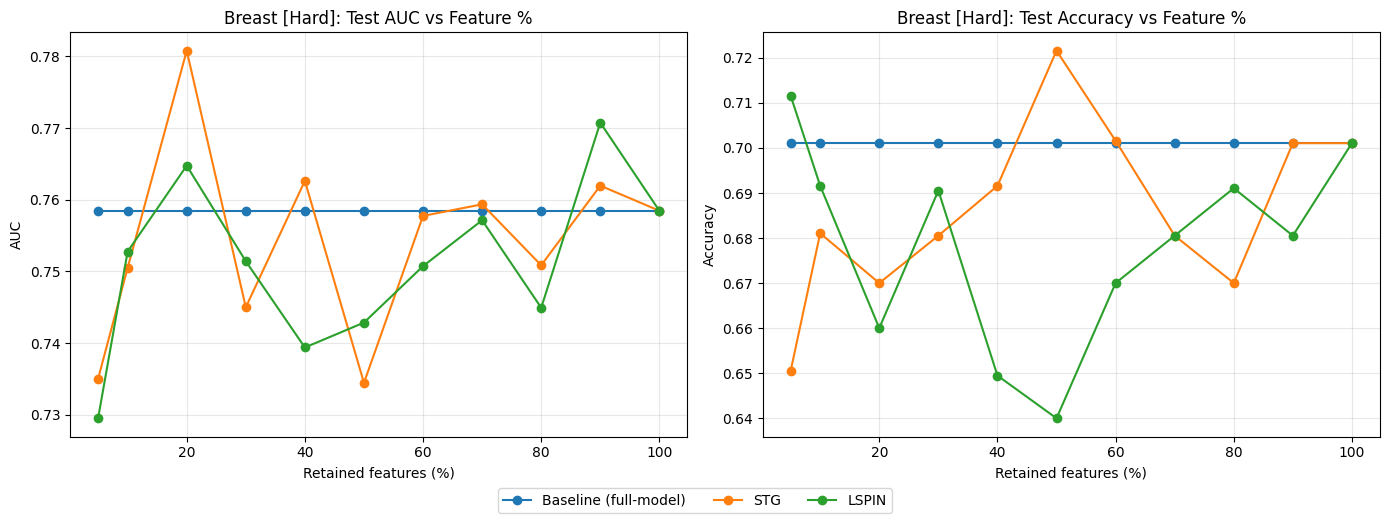

Train-summary columns are missing for Breast; skipped train plot.
Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\RELATHE_test_curves.png


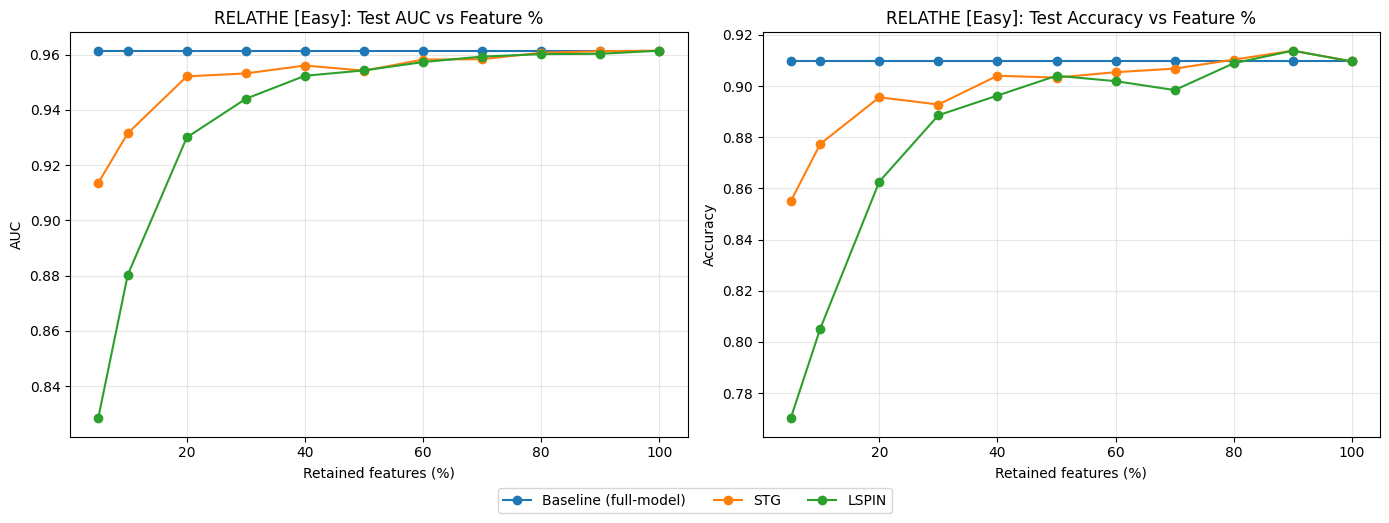

Train-summary columns are missing for RELATHE; skipped train plot.
Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\SMK-CAN-187_test_curves.png


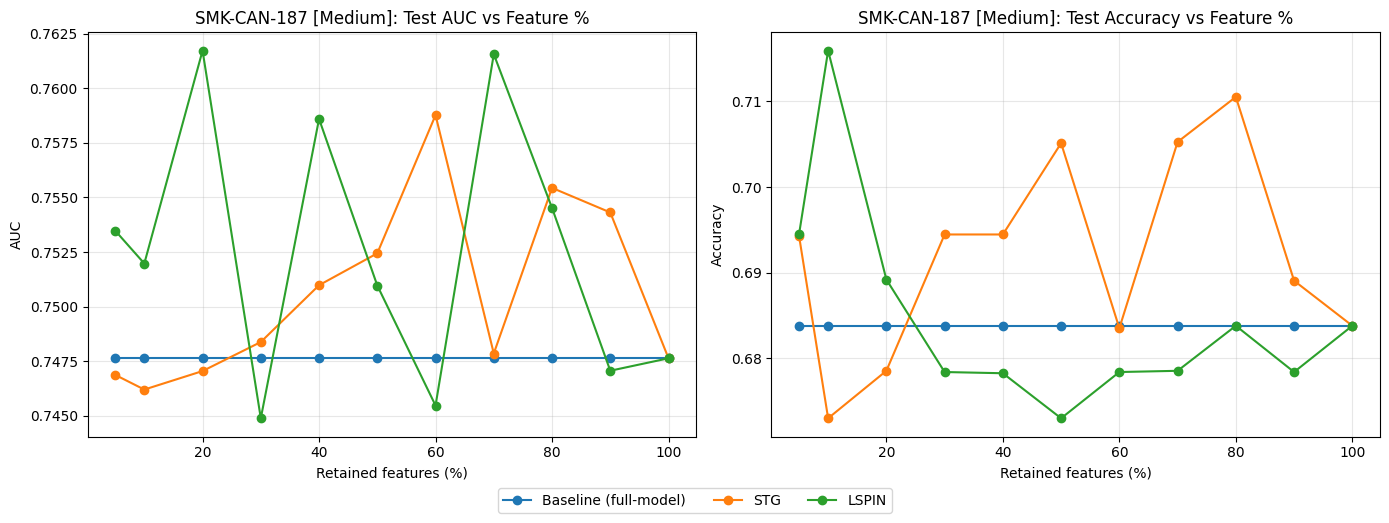

Train-summary columns are missing for SMK-CAN-187; skipped train plot.
Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\colon_test_curves.png


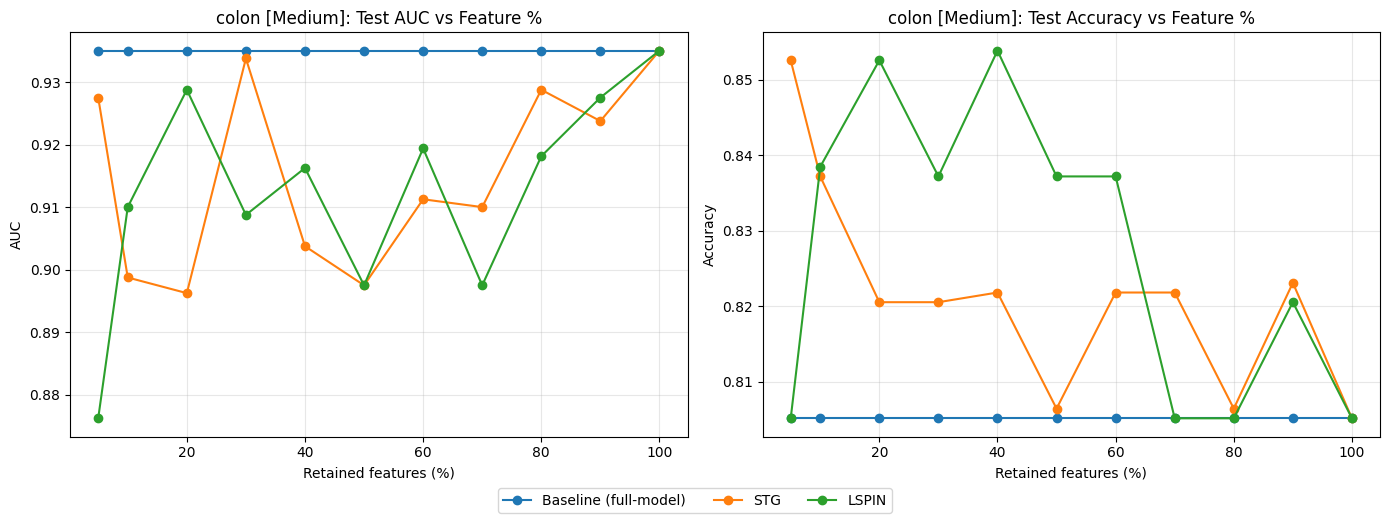

Train-summary columns are missing for colon; skipped train plot.
Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\leukemia_test_curves.png


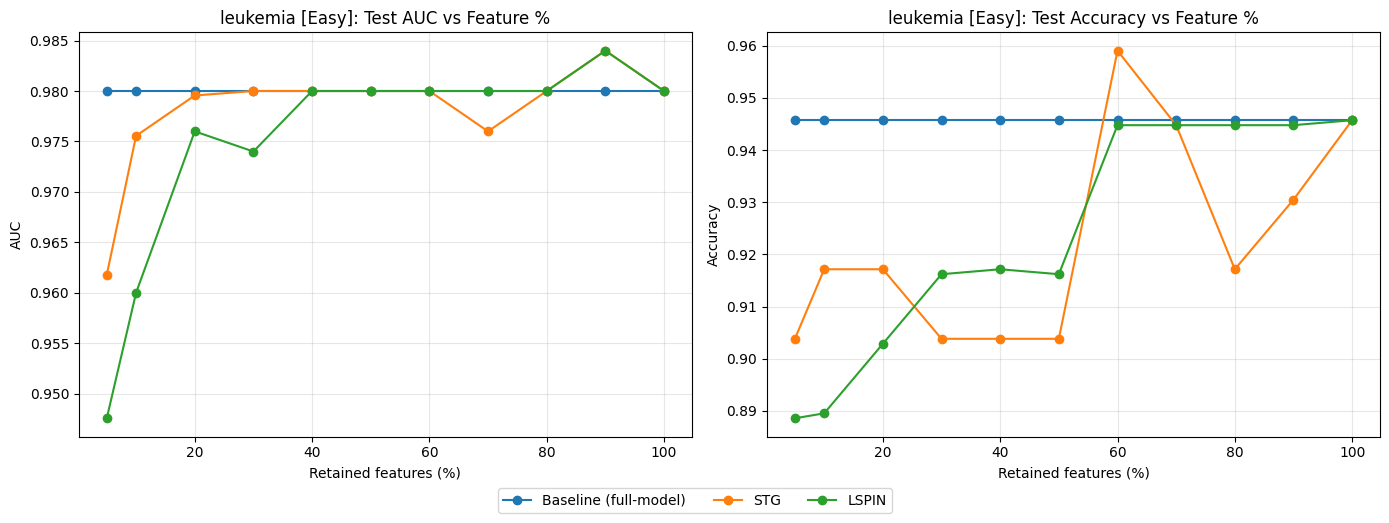

Train-summary columns are missing for leukemia; skipped train plot.
Saved test plot: c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\plots\madelon_test_curves.png


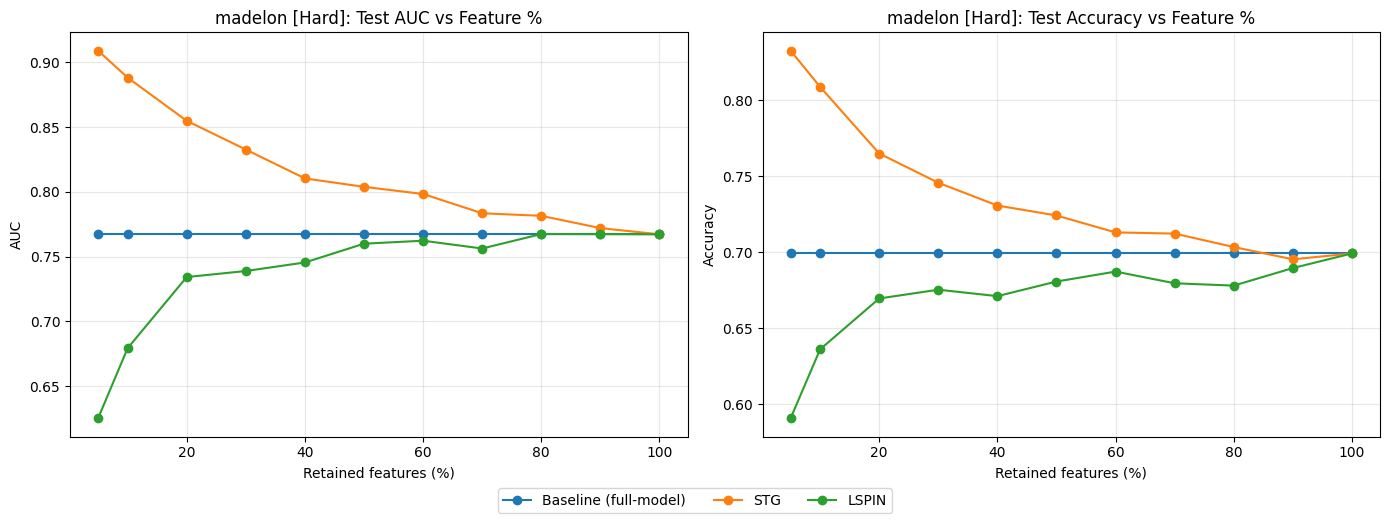

Train-summary columns are missing for madelon; skipped train plot.


In [15]:
difficulty_by_dataset = {}
for idx, name in enumerate(DEFAULT_DATASET_NAMES):
    if idx < 2:
        difficulty_by_dataset[name] = "Hard"
    elif idx < 4:
        difficulty_by_dataset[name] = "Medium"
    else:
        difficulty_by_dataset[name] = "Easy"

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

for dataset_name in sorted(combined_summary_df["dataset"].unique()):
    part = combined_summary_df[combined_summary_df["dataset"] == dataset_name].sort_values("feature_pct")
    difficulty = difficulty_by_dataset.get(dataset_name, "Unknown")

    # Test-set curves
    fig_test, axes_test = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    axes_test[0].plot(part["feature_pct"], part["baseline_auc_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[0].plot(part["feature_pct"], part["stg_auc_mean"], marker="o", label=f"STG")
    axes_test[0].plot(part["feature_pct"], part["lspin_auc_mean"], marker="o", label=f"LSPIN")
    axes_test[0].set_title(f"{dataset_name} [{difficulty}]: Test AUC vs Feature %")
    axes_test[0].set_xlabel("Retained features (%)")
    axes_test[0].set_ylabel("AUC")
    axes_test[0].grid(True, alpha=0.3)

    axes_test[1].plot(part["feature_pct"], part["baseline_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
    axes_test[1].plot(part["feature_pct"], part["stg_accuracy_mean"], marker="o", label=f"STG")
    axes_test[1].plot(part["feature_pct"], part["lspin_accuracy_mean"], marker="o", label=f"LSPIN")
    axes_test[1].set_title(f"{dataset_name} [{difficulty}]: Test Accuracy vs Feature %")
    axes_test[1].set_xlabel("Retained features (%)")
    axes_test[1].set_ylabel("Accuracy")
    axes_test[1].grid(True, alpha=0.3)

    handles_test, labels_test = axes_test[1].get_legend_handles_labels()
    fig_test.legend(handles_test, labels_test, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig_test.tight_layout()

    test_plot_path = plots_dir / f"{dataset_name}_test_curves.png"
    fig_test.savefig(test_plot_path, dpi=150, bbox_inches="tight")
    print(f"Saved test plot: {test_plot_path}")
    plt.show()

    # Train-set curves (only if present in summary columns)
    train_cols = {
        "baseline_train_auc_mean", "stg_train_auc_mean", "lspin_train_auc_mean",
        "baseline_train_accuracy_mean", "stg_train_accuracy_mean", "lspin_train_accuracy_mean",
    }
    if train_cols.issubset(part.columns):
        fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        axes_train[0].plot(part["feature_pct"], part["baseline_train_auc_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[0].plot(part["feature_pct"], part["stg_train_auc_mean"], marker="o", label=f"STG")
        axes_train[0].plot(part["feature_pct"], part["lspin_train_auc_mean"], marker="o", label=f"LSPIN")
        axes_train[0].set_title(f"{dataset_name} [{difficulty}]: Train AUC vs Feature %")
        axes_train[0].set_xlabel("Retained features (%)")
        axes_train[0].set_ylabel("AUC")
        axes_train[0].grid(True, alpha=0.3)

        axes_train[1].plot(part["feature_pct"], part["baseline_train_accuracy_mean"], marker="o", label=f"Baseline (full-model)")
        axes_train[1].plot(part["feature_pct"], part["stg_train_accuracy_mean"], marker="o", label=f"STG")
        axes_train[1].plot(part["feature_pct"], part["lspin_train_accuracy_mean"], marker="o", label=f"LSPIN")
        axes_train[1].set_title(f"{dataset_name} [{difficulty}]: Train Accuracy vs Feature %")
        axes_train[1].set_xlabel("Retained features (%)")
        axes_train[1].set_ylabel("Accuracy")
        axes_train[1].grid(True, alpha=0.3)

        handles_train, labels_train = axes_train[1].get_legend_handles_labels()
        fig_train.legend(handles_train, labels_train, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
        fig_train.tight_layout()

        train_plot_path = plots_dir / f"{dataset_name}_train_curves.png"
        fig_train.savefig(train_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved train plot: {train_plot_path}")
        plt.show()
    else:
        print(f"Train-summary columns are missing for {dataset_name}; skipped train plot.")

## Write Outputs to Separate Files

All outputs are written to the output folder. The source ETree file is never modified.

In [ ]:
summary_csv = OUTPUT_DIR / "iterative_feature_curve_summary.csv"
fold_csv = OUTPUT_DIR / "iterative_feature_curve_fold_results.csv"

combined_summary_df.to_csv(summary_csv, index=False)
combined_fold_df.to_csv(fold_csv, index=False)

print("Saved:")
print("-", summary_csv)
print("-", fold_csv)

Saved:
- c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\iterative_feature_curve_summary.csv
- c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\iterative_feature_curve_fold_results.csv
- c:\Users\shlom\Thesis\FeatureSelect-Benchmark-Hub\output\etree_source_metadata.xml


## Repeatable Execution Checks

Run this cell anytime to quickly re-check output artifacts without rerunning model training.

In [ ]:
checks = {
    "summary_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_summary.csv").exists(),
    "fold_csv_exists": (OUTPUT_DIR / "iterative_feature_curve_fold_results.csv").exists(),
}

check_df = pd.DataFrame([checks])
display(check_df)

if not all(checks.values()):
    raise RuntimeError("One or more repeatability checks failed.")

print("All repeatability checks passed.")

,summary_csv_exists,fold_csv_exists,metadata_xml_exists,etree_unchanged
0,True,True,True,True


All repeatability checks passed.
